# Lab: Multi-Class Classification

---

## 1. Introduction
In this lab, we'll work with a real-world dataset to predict a person's obesity risk level, which falls into one of several categories. This is a classic multi-class classification problem.

* **Goal:** To preprocess a dataset with mixed data types and train a logistic regression model to predict obesity levels.
* **Data:** The "Obesity Risk Prediction" dataset, which includes demographic data, eating habits, and physical activity information.
* **Strategies:** We will implement and compare the direct multinomial approach with the One-vs-One (OvO) strategy.

---

## 2. Setup and Data Loading

First, let's import the necessary libraries for data processing, modeling, and evaluation.

In [55]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [56]:
# Load the data from the URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
data = pd.read_csv(url)

# Display a sample of the data
data.sample(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2065,Female,21.674470,1.719780,132.262558,yes,yes,3.0,3.0,Sometimes,no,1.777805,no,1.584716,0.927341,Sometimes,Public_Transportation,Obesity_Type_III
69,Male,23.000000,1.800000,60.000000,yes,no,2.0,3.0,no,no,3.000000,no,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
241,Male,22.000000,1.600000,66.000000,no,yes,3.0,3.0,Sometimes,no,2.000000,no,3.000000,0.000000,no,Bike,Overweight_Level_I
362,Female,37.000000,1.650000,73.000000,yes,no,3.0,3.0,Sometimes,no,2.000000,no,1.000000,0.000000,Sometimes,Automobile,Overweight_Level_I
1995,Female,20.388049,1.777971,137.785027,yes,yes,3.0,3.0,Sometimes,no,2.702789,no,1.606109,0.731213,Sometimes,Public_Transportation,Obesity_Type_III



---

## 3. Exploratory Data Analysis (EDA)

Let's start by understanding our target variable, `NObeyesdad`. A count plot will show us the distribution of the different obesity levels in the dataset.

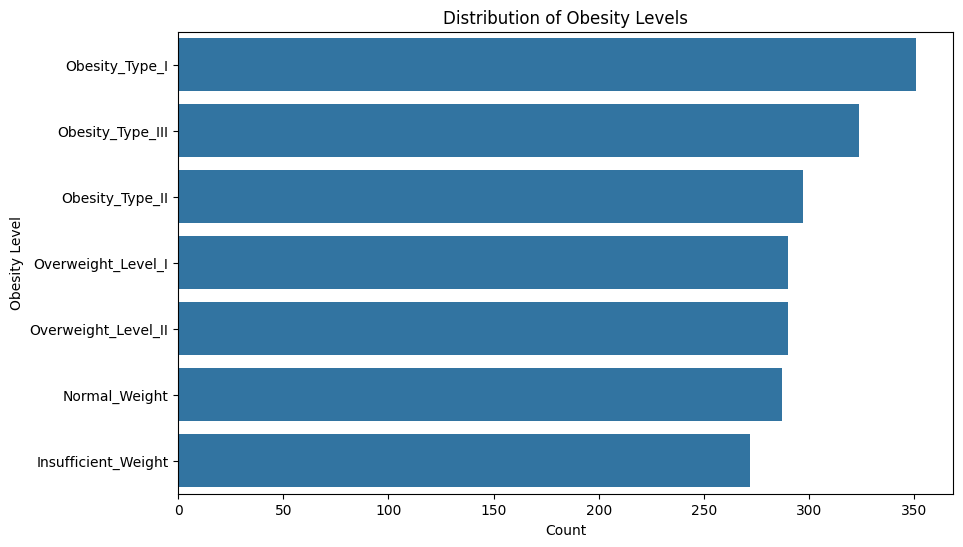

In [57]:
# Visualize the distribution of the target variable
plt.figure(figsize=(10,6))
sns.countplot(data, y='NObeyesdad', order = data['NObeyesdad'].value_counts().index)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.show()

> 🔍 **Observation:**  
> The classes are reasonably balanced, which is good. We don't have a situation where one class overwhelmingly dominates the others, so accuracy can be a meaningful metric.  

---

## 4. Data Preprocessing

This dataset contains a mix of numerical and categorical features. We need to prepare them properly before feeding them into our model. 

### 4.1. Identify Feature Types
First, we'll separate our columns into numerical and categorical types.

In [58]:
# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable from the `categorical_cols`
target_col = 'NObeyesdad'
categorical_cols.remove(target_col)

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")

Numerical features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


### 4.2. Separate Features (X) and Target (y)

Let's define our feature matrix `X` and target vector `y`.

In [59]:
X = data.drop(target_col, axis=1)
y = data[target_col]

### 4.3. Split Data into Training and Testing Sets
This is the **most important first step** in preprocessing. We split the data *before* applying any scaling or encoding to prevent data leakage from the test set into our training process. We use `stratify=y` to ensure the class distribution is the same in both the train and test sets.

In [60]:
# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 4.4. Create a Preprocessing Pipeline
We will use `ColumnTransformer` to apply different transformations to different columns:
* `StandardScaler` will be applied to the numerical columns.
* `OneHotEncoder` will be applied to the categorical columns.

We will `fit` this transformer **only on the training data**.

In [61]:
# Create a preprocessor object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any)
)

# Fit the preprocessor on the training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Use the same fitted preprocessor to transform the test data
X_test_processed = preprocessor.transform(X_test)


---

## 5. Model 1: Logictic Regression with a Multinomial Approach

In the lecture, we learned about the **One-vs-All** strategy where you train one binary classifier for each class. While there's a great concept to understand, `scikit-learn`'s `LogisticRegression` offers a more direct and often better-performing method for multi-class problems.

This is the **"multinomial"** approach. Instead of training multiple separate binary models, it trains a single model that can handle all classes at once. This is generally more efficient and is now the recommended best practice.

By default, `scikit-learn` will automatically use this superior multinomial approach when it detects a multi-class problem.

In [62]:
# Train a logistic regression model using the multinomial strategy
# We use the default parameters, so scikit-learn automatically selects the 'multinomial' approach.
model_multinomial = LogisticRegression(max_iter=1000)
model_multinomial.fit(X_train_processed, y_train)

# Make predictions on the processed test data
y_pred_multinomial = model_multinomial.predict(X_test_processed)


---

## 6. Model 2: Logistic Regression with One-vs-One
The One-vs-One strategy involves training one classifier for every possible pair of classes. For a new data point, the class that receives the most "votes" from these pairwise classifiers is selected. We can implement this using scikit-learn's `OneVsOneClassifier` wrapper.

In [63]:
# Create a base logistic regression model
# The 'liblinear' solver is efficient for the binary classification sub-problems that OvO creates
base_lr = LogisticRegression(solver='liblinear')

# Wrap the base model with OneVsOneClassifier
model_ovo = OneVsOneClassifier(base_lr)

# Training the OvO model
model_ovo.fit(X_train_processed, y_train)

# Make predictions
y_pred_ovo = model_ovo.predict(X_test_processed)


---

## 7. Comparing the Models
Let's start with generating the classification reports for our models.

In [64]:
# Evaluate the model
print("=================== Multinomial Strategy ===================\n")
print(classification_report(y_test, y_pred_multinomial))

# Evaluate the model
print("=================== One-vs-One Strategy ====================\n")
print(classification_report(y_test, y_pred_ovo))
print("="*60)

=================== Multinomial Strategy ===================

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        54
      Normal_Weight       0.81      0.74      0.77        58
     Obesity_Type_I       0.88      0.91      0.90        70
    Obesity_Type_II       0.94      0.97      0.95        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.74      0.74      0.74        58
Overweight_Level_II       0.81      0.76      0.79        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423

=================== One-vs-One Strategy ====================

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.83      0.76      0.79        58
     Obesity_Type_

### Confusion Matrices
Now, let's visualize the performance of both models using confusion matrices.

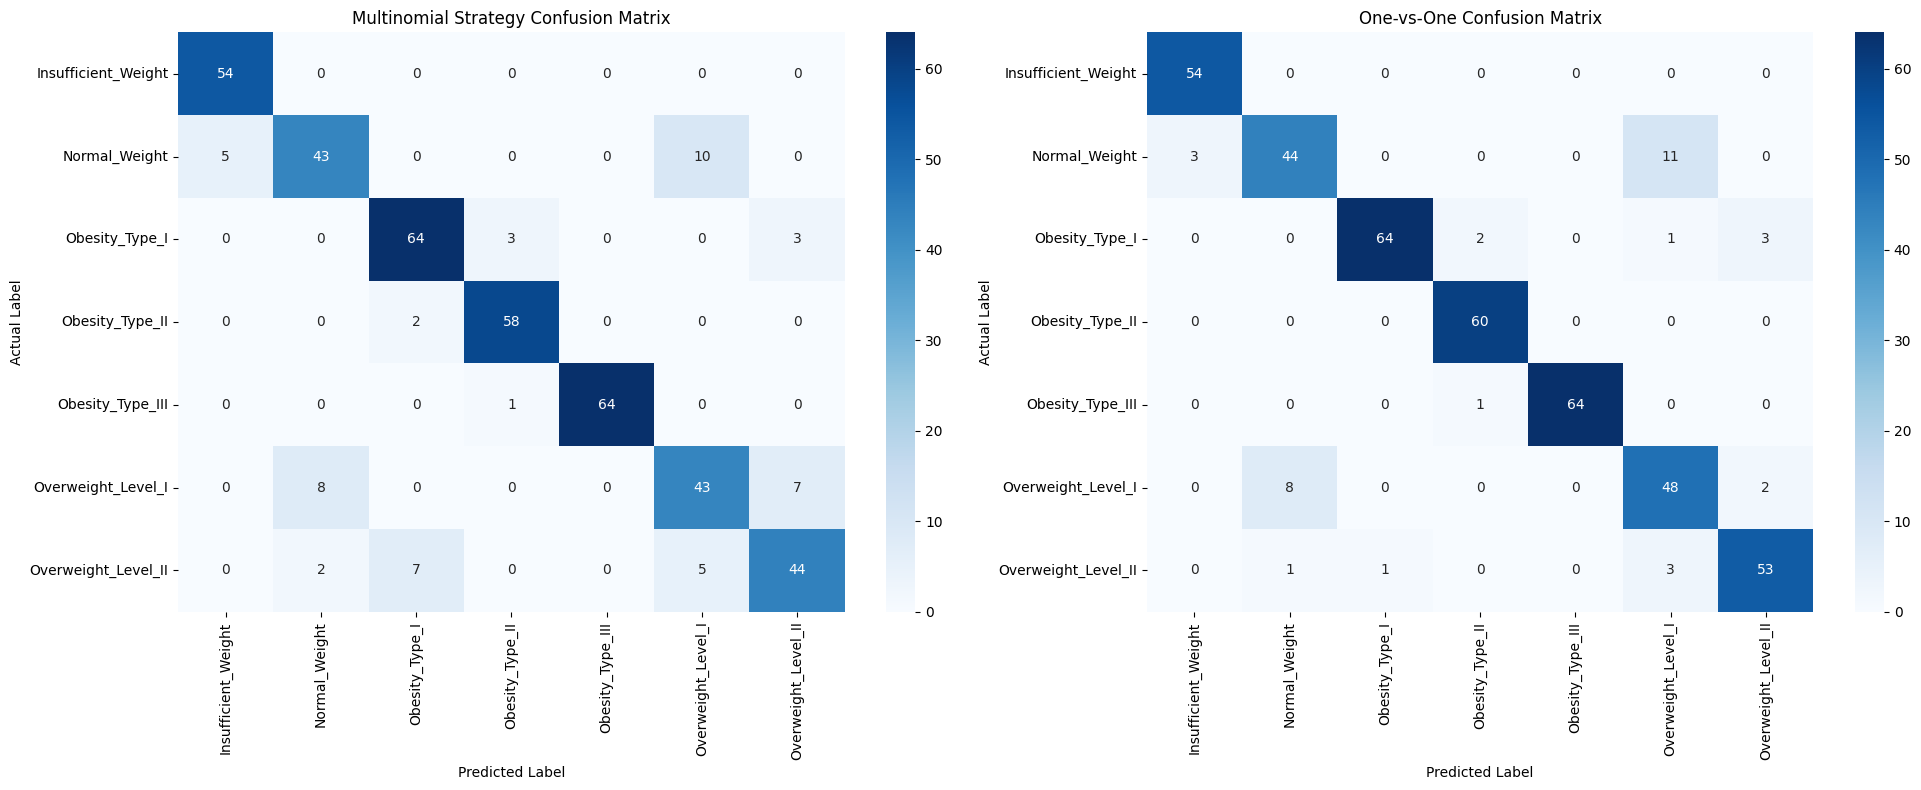

In [65]:
# Compute confusion matrices
cm_multinomial = confusion_matrix(y_test, y_pred_multinomial)
cm_ovo = confusion_matrix(y_test, y_pred_ovo)
class_labels = sorted(y.unique())

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Multinomial Confusion Matrix
sns.heatmap(cm_multinomial, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title("Multinomial Strategy Confusion Matrix")
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# OvO Confusion Matrix
sns.heatmap(cm_ovo, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=class_labels, yticklabels=class_labels)
axes[1].set_title("One-vs-One Confusion Matrix")
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

### Conclusion

After training and evaluating both models, we can draw a clear conclusion from the classification reports. 

While both models performed well, the **One-vs-One (OvO) strategy was demonstrably superior** on this dataset.

* **Overall Accuracy:** The OvO model achieved an overall accuracy of **91%** compared to the multinomial model's **87%**. This 4% improvement is a significant gain.

* **Per-Class Performance:** Looking at the F1-scores for each class, the OvO model consistently outperformed the multinomial model across the board. The improvement was particularly noticeable for the more nuanced, "in-between" categories that are likely harder to distinguish:
    * `Overweight_Level_II`: F1-score improved from 0.79 to **0.91**.
    * `Obesity_Type_I`: F1-score improved from 0.90 to **0.95**.
    * `Overweight_Level_I`: F1-score improved from 0.74 to **0.79**.

**Why was OvO better here?** The OvO strategy works by training a dedicated binary classifier for every single pair of classes (e.g., one classifier just for distinguishing `Normal_Weight` vs. `Overweight_Level_I`). This approach allows the model to learn the specific, subtle decision boundaries between very similar classes, which is where the multinomial model struggled more.

> 📝 **Final Takeaway:** While the direct multinomial approach is often a great and efficient starting point, this analysis proves that it is always worthwhile to experiment with different multi-class strategies. For problems with many closely related categories, the **One-vs-One (OvO)** approach can provide a significant performance boost by breaking the complex problem down into simpler, pairwise decisions.

---

**Next:** [Decision Trees](./03_decision_trees.md)